In [5]:
# https://www.kaggle.com/datasets/guesejustin/cifar10-keras-files-cifar10load-data

In [6]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
#!/bin/bash
!curl -L -o cifar10-keras-files-cifar10load-data.zip\
  https://www.kaggle.com/api/v1/datasets/download/guesejustin/cifar10-keras-files-cifar10load-data

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  161M  100  161M    0     0  95.2M      0  0:00:01  0:00:01 --:--:--  125M


In [4]:
!unzip /content/cifar10-keras-files-cifar10load-data.zip

Archive:  /content/cifar10-keras-files-cifar10load-data.zip
  inflating: cifar-10.npz            


In [7]:
file = 'cifar-10.npz'

with np.load(file) as data:
  X_train = data['x_train']
  y_train = data['y_train']
  X_test = data['x_test']
  y_test = data['y_test']

In [8]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

In [10]:
X_train.shape

(50000, 32, 32, 3)

In [11]:
X_train.dtype

dtype('uint8')

In [12]:
y_train.shape

(50000, 1)

In [14]:
X_test.shape

(10000, 32, 32, 3)

In [16]:
X_train.min()

np.uint8(0)

In [17]:
X_train.max()

np.uint8(255)

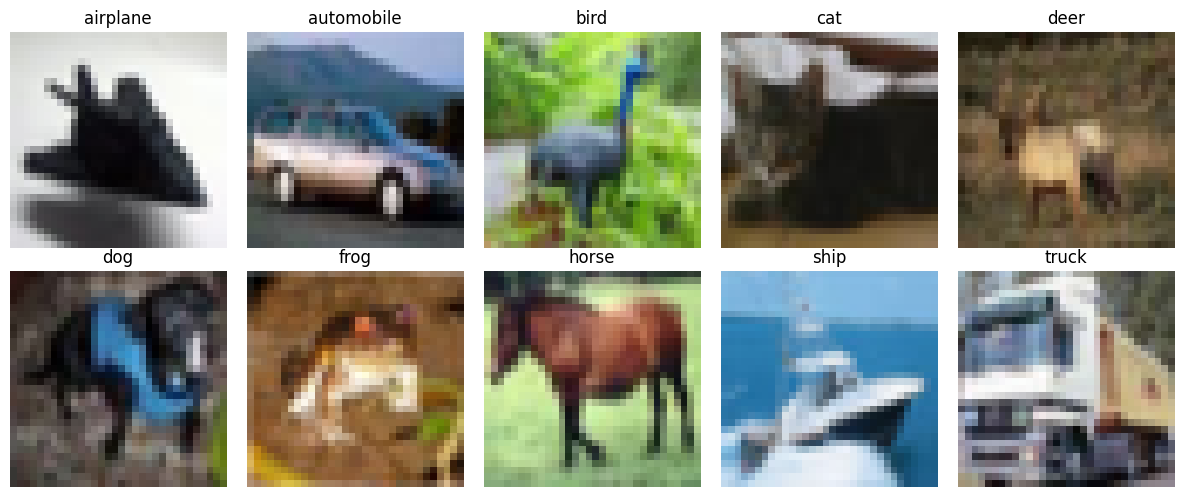

In [18]:
plt.figure(figsize=(12, 5))

for i in range(10):
    idx = np.where(y_train == i)[0][0]

    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[idx])
    plt.title(class_names[i], fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [19]:
from tensorflow.keras.utils import to_categorical

In [21]:
X_train_norm = X_train.astype('float32') / 255.0

X_test_norm = X_test.astype('float32') / 255.0

In [22]:
y_train_flat = y_train.flatten()

y_test_flat = y_test.flatten()

In [23]:
X_train_norm.dtype

dtype('float32')

In [24]:
y_train_flat[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [25]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [27]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [31]:
history = model.fit(
    X_train_norm, y_train_flat,
    epochs=10,
    batch_size=64,
    validation_data=(X_test_norm, y_test_flat)
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 37s 46ms/step - accuracy: 0.4352 - loss: 1.5692 - val_accuracy: 0.5345 - val_loss: 1.3142
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 46ms/step - accuracy: 0.5730 - loss: 1.2166 - val_accuracy: 0.6081 - val_loss: 1.1306
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 45ms/step - accuracy: 0.6207 - loss: 1.0823 - val_accuracy: 0.6414 - val_loss: 1.0456
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.6535 - loss: 0.9977 - val_accuracy: 0.6446 - val_loss: 1.0195
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 45ms/step - accuracy: 0.6715 - loss: 0.9391 - val_accuracy: 0.6632 - val_loss: 0.9765
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.6915 - loss: 0.8892 - val_accuracy: 0.6600 - val_loss: 0.9898
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.7081 - loss: 0.8440 - val_accuracy: 0.6757 - val_loss: 0.9447
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.7230 - loss: 0.8033 - 

In [32]:
improved_model = models.Sequential([

    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

In [33]:
improved_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 552,874 (2.11 MB)

 Trainable params: 551,722 (2.10 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [34]:
improved_model.compile(optimizer='adam',
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

In [35]:
history_improved = improved_model.fit(X_train_norm, y_train_flat,
                                       epochs=15,
                                       batch_size=64,
                                       validation_data=(X_test_norm, y_test_flat))

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 280s 353ms/step - accuracy: 0.4322 - loss: 1.6562 - val_accuracy: 0.5650 - val_loss: 1.2208
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 269s 344ms/step - accuracy: 0.6098 - loss: 1.1026 - val_accuracy: 0.6842 - val_loss: 0.8903
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 331s 356ms/step - accuracy: 0.6804 - loss: 0.9079 - val_accuracy: 0.7114 - val_loss: 0.8135
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 273s 348ms/step - accuracy: 0.7212 - loss: 0.8033 - val_accuracy: 0.6908 - val_loss: 0.8727
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 319s 345ms/step - accuracy: 0.7479 - loss: 0.7308 - val_accuracy: 0.7048 - val_loss: 0.8743
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 322s 345ms/step - accuracy: 0.7696 - loss: 0.6687 - val_accuracy: 0.7553 - val_loss: 0.6990
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 329s 354ms/step - accuracy: 0.7839 - loss: 0.6275 - val_accuracy: 0.7937 - val_loss: 0.6028
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 269s 344ms/step - accuracy: 0.7972 -

In [36]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomZoom(0.1)
])

In [37]:
final_model = models.Sequential([

    layers.Input(shape=(32, 32, 3)),
    data_augmentation,

    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

In [38]:
final_model.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

In [39]:
history_final = final_model.fit(X_train_norm, y_train_flat,
                                 epochs=20,
                                 batch_size=64,
                                 validation_data=(X_test_norm, y_test_flat))

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 325s 409ms/step - accuracy: 0.3576 - loss: 1.8747 - val_accuracy: 0.4229 - val_loss: 1.6427
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 320s 410ms/step - accuracy: 0.4823 - loss: 1.4329 - val_accuracy: 0.5285 - val_loss: 1.3636
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 285s 365ms/step - accuracy: 0.5416 - loss: 1.2771 - val_accuracy: 0.5354 - val_loss: 1.3701
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 278s 355ms/step - accuracy: 0.5839 - loss: 1.1735 - val_accuracy: 0.5425 - val_loss: 1.3777
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 336s 373ms/step - accuracy: 0.6155 - loss: 1.0943 - val_accuracy: 0.6464 - val_loss: 1.0488
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 289s 369ms/step - accuracy: 0.6373 - loss: 1.0443 - val_accuracy: 0.6465 - val_loss: 1.0566
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 310s 397ms/step - accuracy: 0.6532 - loss: 0.9961 - val_accuracy: 0.6789 - val_loss: 0.9606
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 294s 375ms/step - accuracy: 0.6712 -

In [40]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [41]:
y_pred_probs = final_model.predict(X_test_norm)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 46ms/step


In [42]:
print(classification_report(y_test_flat, y_pred_classes, target_names=class_names))

              precision    recall  f1-score   support

    airplane       0.78      0.79      0.78      1000
  automobile       0.74      0.96      0.83      1000
        bird       0.78      0.58      0.67      1000
         cat       0.74      0.51      0.60      1000
        deer       0.73      0.72      0.72      1000
         dog       0.85      0.56      0.68      1000
        frog       0.52      0.95      0.67      1000
       horse       0.86      0.81      0.83      1000
        ship       0.96      0.69      0.80      1000
       truck       0.78      0.85      0.81      1000

    accuracy                           0.74     10000
   macro avg       0.77      0.74      0.74     10000
weighted avg       0.77      0.74      0.74     10000



In [43]:
cm = confusion_matrix(y_test_flat, y_pred_classes)

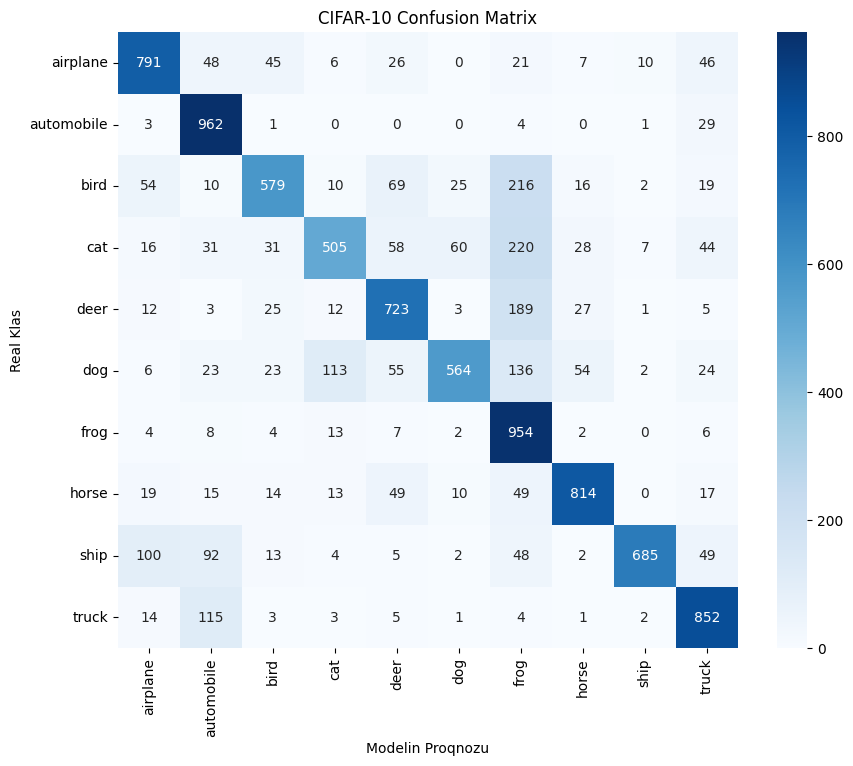

In [46]:
plt.figure(figsize=(10, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Modelin Proqnozu')
plt.ylabel('Real Klas')
plt.title('CIFAR-10 Confusion Matrix')
plt.show()

In [47]:
sample_idx = 55
test_image = X_test_norm[sample_idx]
real_label = class_names[y_test_flat[sample_idx]]

input_image = np.expand_dims(test_image, axis=0)

pred_probs = final_model.predict(input_image)
pred_class_idx = np.argmax(pred_probs)
pred_label = class_names[pred_class_idx]
confidence = pred_probs[0][pred_class_idx] * 100

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


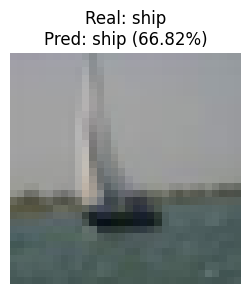

In [48]:
plt.figure(figsize=(3, 3))
plt.imshow(X_test[sample_idx])
plt.title(f"Real: {real_label}\nPred: {pred_label} ({confidence:.2f}%)")
plt.axis('off')
plt.show()